# NB03f — Derived Product Audit and Plan-Based Prune

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.



| Field | Value |
|-------|-------|
| **Notebook** | `03f_bda_Product_Audit_Prune2_v12.ipynb` |
| **Version** | v12 |
| **Pipeline position** | QA/Maintenance. After NB03e (derived products), before NB04a (QC/QA). |
| **Last validated** | 2026-04-XX |

## Narrative

Audits and optionally prunes **derived products only** — outputs from NB03e
(composites, temporal stats, rolling windows, z-scores, block stats, landuse,
cloud masks, NBR, RGB, visibility/fire). Does NOT touch source TIFs from
NB03a/b/c — that is NB03d's job.

**Separation of concerns:**
- **NB03d** audits SOURCE products (raw COH, CARD, MS TIFs)
- **NB03f** audits DERIVED products (everything NB03e creates)

The notebook operates in three phases:

**Phase 1 — CLEANUP** (runs first, before scan/audit):
Bulk delete products marked for regeneration by NB03e. Controlled by per-product
toggles. This enables a clean NB03e rerun without stale products accumulating.
- Baseline composite RGBs: always deleted (visual junk, no downstream use)
- Temporal products: optional bulk wipe (`DELETE_ALL_TEMPORAL`)
- MS composites/NBR/RGB/cloud masks/landuse: per-product toggles

**Phase 2 — SCAN + RENAME:**
Count remaining derived products per city after cleanup. Migrate legacy filenames
to the double-underscore convention via `stack_align_rename.py`.

**Phase 3 — THREE-PASS AUDIT** (on remaining products):
- **D1-ORPHAN-DATE**: Flag derived TIFs whose source dates are NOT in `nb02a_scene_plan.json`. CARD dates allow +-7 day tolerance (`CARD_DATE_TOLERANCE_DAYS=7`) because actual CARD acquisition dates can differ slightly from plan dates.
- **D2-STALE-AGGREGATE**: Flag aggregate products (temporal_stats, coherence_baseline, rolling_stats, block_stats) older than the last NB03d source prune timestamp in bda.sqlite. If sources were pruned, derived products from those sources are stale.
- **D3-INVALID-WINDOW**: Flag rolling products with window sizes not in `ROLLING_WINDOW_SIZES` (default [3, 7, 13]). Catches orphans from the purged roll2/roll5 (~421 GB deleted).

Flagged files are quarantined to `_quarantine/`, not deleted. All results synced to bda.sqlite.

## Scientific Rationale
Derived product hygiene is critical because stale/orphaned products silently corrupt
feature extraction in NB05a. A rolling_stats TIF from a purged window size would inject
NaN or incorrect features. Stale aggregate products computed from later-pruned source TIFs
would carry contamination forward. The D2 stale check is specifically designed to catch
this: if NB03d pruned a wrong-orbit CARD scene, all temporal_stats that included that
scene are now invalid and must be regenerated.

## Inputs

| Data | Source | Format |
|------|--------|--------|
| `nb02a_scene_plan.json` | NB02a | JSON (expected dates per city) |
| Derived TIFs: temporal_stats, coherence_baseline, rolling, rolling_stats, block_stats | NB03e (TEMPORAL_ROOT, SAR dirs) | GeoTIFF |
| Derived TIFs: composites, landuse, NBR, cloud masks, RGB, visibility | NB03e (MS_DIR) | GeoTIFF |
| `bda.sqlite` | NB03d | Last prune timestamp for D2 check |

## Outputs

| Artifact | Path | Used by |
|----------|------|---------|
| Quarantined derived TIFs | `SATELLITE_DIR/_quarantine/` | Recovery if needed |
| Renamed derived TIFs (__ convention) | In-place in source dirs | NB04a, NB05a |
| Cleaned product directories | In-place | NB04a (QC/QA) → NB05a |
| `bda.sqlite` (derived_audit table) | `CATALOG_DB` | Audit trail |

## Prerequisites
- NB03e must have run (derived products exist)
- NB03d recommended (source products clean before deriving)
- NB02a must have run (plan exists for date checking)

## Key Methodological Choices

| Choice | Justification | Reference |
|--------|---------------|-----------|
| Derived-only scope | Separation from NB03d source audit | Architecture principle |
| Phase 1 cleanup before audit | Avoid auditing products about to be deleted | Efficiency |
| CARD_DATE_TOLERANCE_DAYS=7 | CARD actual dates can drift from plan | Empirical |
| D2 stale check vs bda.sqlite | Catches products from pruned sources | Data integrity |
| D3 valid windows = [3, 7, 13] | roll2/roll5 purged, catch orphans | Config consistency |
| Quarantine, not delete | Reversible | Safety |
| DRY_RUN=True/False toggles | Separate cleanup vs audit dry run control | Flexibility |

## Cell Structure

| Cell | ID | What | Lines | Status |
|------|----|------|-------|--------|
| 0 | — | Documentation (this cell) | — | — |
| 1 | CONFIG | Config (DRY_RUN flags, DELETE toggles) | 17 | Config |
| 2 | SETUP | Load global_setup | 10 | Config |
| 3 | CLEANUP | Phase 1: Delete derived products marked for regen | 193 | **Core** |
| 4 | SCAN | Count remaining derived products per city | 135 | **Core** |
| 5 | SCAN-TEMPORAL | Detailed TEMPORAL_ROOT breakdown | 47 | Diagnostic |
| 6 | RENAME | Migrate to __ naming convention | 143 | **Core** |
| 7 | PLAN-LOAD | Read unified scene plan | 90 | **Core** |
| 8 | D1-ORPHAN-DATE | Flag derived TIFs with dates not in plan | 165 | **Core** |
| 9 | D2-STALE-AGGREGATE | Flag products older than last NB03d prune | 82 | **Core** |
| 10 | D3-INVALID-WINDOW | Flag rolling TIFs with wrong window sizes | 71 | **Core** |
| 11 | PRUNE | Quarantine flagged files (D1+D2+D3) | 106 | Optional |
| 12 | SQLITE | Sync audit + prune to bda.sqlite | 72 | **Core** |
| 13 | SUMMARY | Completion report | 34 | QA |

## Thesis Mapping

| Thesis Section | Cells | Content |
|----------------|-------|---------|
| 3.3 Preprocessing — Quality Control | D1, D2, D3 | Three-pass derived product audit |
| 3.3 Preprocessing — Data Management | CLEANUP, PRUNE | Cleanup strategy, quarantine |

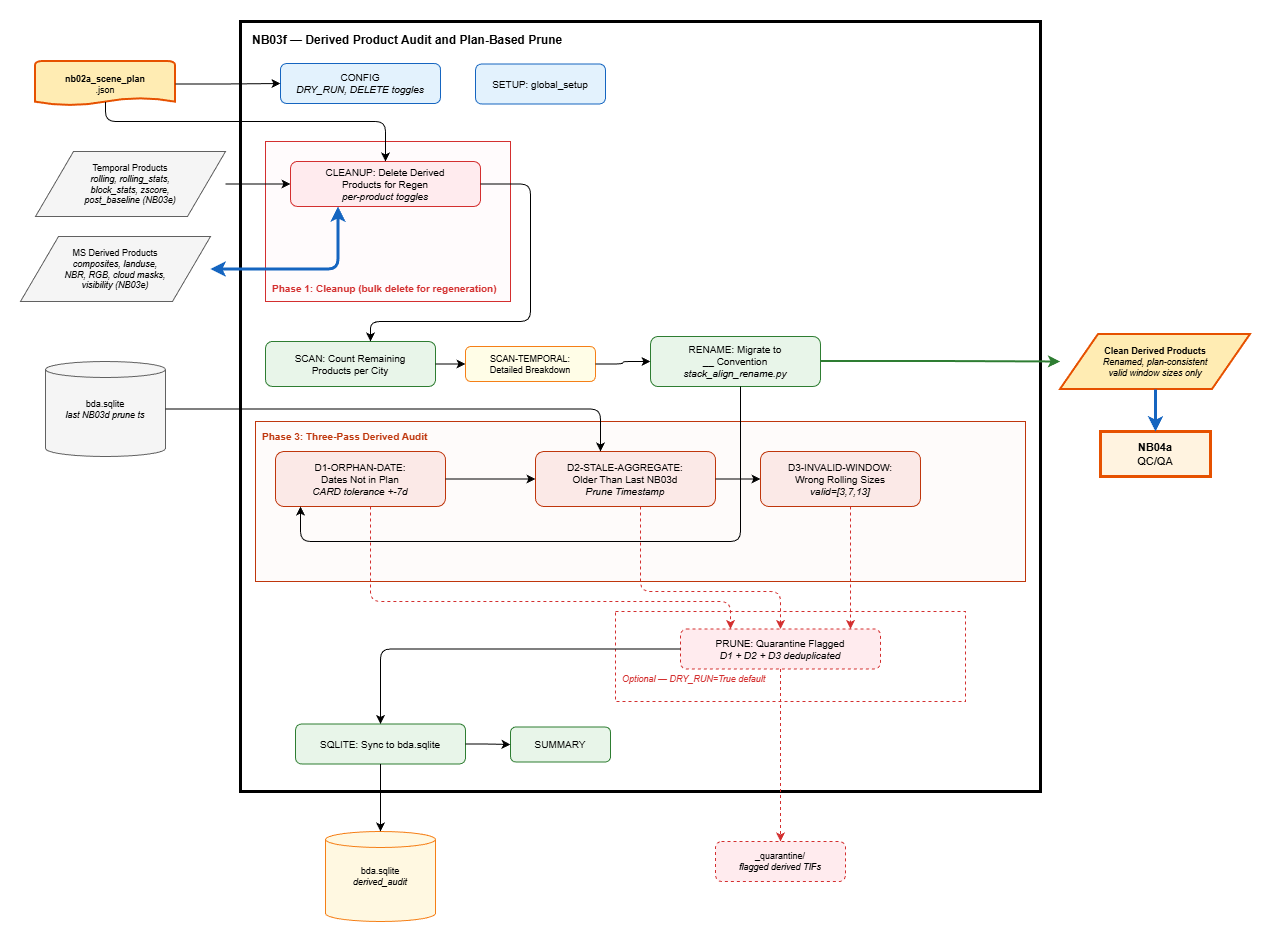

In [1]:
# @title CELL CONFIG
NOTEBOOK_ID = 'NB03f'
TIER_SELECTION = [0, 1, 2, 3, 4, 5]
DRY_RUN_RENAME = False         # True = report only, False = execute renames
DRY_RUN_PRUNE = False          # True = report only, False = execute deletes
VERBOSE = True

# --- CLEANUP TOGGLES (Phase 1) ---
# Set True to wipe entire product category for regeneration by NB03e.
# Products NOT wiped here will be audited by D1/D2/D3 passes.
DELETE_ALL_TEMPORAL = True    # rolling, rolling_stats, block_stats, post_baseline, zscore
DELETE_MS_COMPOSITES = True   # composites/{period}/ (bands, indices, landuse, obs_count, cloud_freq, visibility)
DELETE_MS_NBR = True          # nbr/ (per-scene NBR + dNBR/RBR)
DELETE_MS_RGB = True          # rgb/ (per-scene RGB; composite RGBs always deleted as junk)
DELETE_MS_CLOUD_MASKS = True  # s2__cloud_mask__*.tif (per-scene)
DELETE_MS_LANDUSE = True      # LANDUSE_DIR/{city}/ (classification + indices + stats)

# --- D4 CORRUPTION DETECTION (targeted, per-file) ---
# Scans existing derived SAR/MS products for -100 sentinel contamination and
# implausible baseline statistics (mirrors NB03e v43 write-time checks).
# Flags corrupt files for quarantine via the same pipeline as D1/D2/D3.
# Use this when DELETE_ALL_TEMPORAL=False to keep clean products and remove
# only the bad ones. When DELETE_ALL_TEMPORAL=True, most targets are already
# wiped upfront, so D4 has little to do (but still runs harmlessly).
ENABLE_D4_CORRUPT = True


In [2]:
# @title CELL SETUP: LOAD GLOBAL ENVIRONMENT
import platform, os
if platform.system() == 'Windows':
    _setup = r'F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'
with open(_setup) as f:
    exec(f.read())

BDA GLOBAL SETUP
Started: 2026-04-20 20:08:32
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2, 3, 4, 5]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: False
  CITIES_TO_PROCESS: 50 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:545: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     912.7/7452.0 GB (6539.3 GB free)
  GDrive (F:)     1263.5/3726.0 GB (2462.5 GB free)
  Local data      11530.2/14901.9 GB (3371.7 GB free)
  Data stack      1263.5/3726.0 GB (2462.5 GB free)
  WSL ext4        91.4/1006.9 GB (864.2 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 50, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

In [3]:
# @title CELL CLEANUP: DELETE DERIVED PRODUCTS BEFORE AUDIT
# Runs BEFORE scan/rename/audit. Deletes products marked for regeneration.
# Products NOT deleted here will be audited by D1/D2/D3 passes below.
import os, shutil, re
from pathlib import Path
from collections import defaultdict

print('=' * 80)
print('CLEANUP: DELETE DERIVED PRODUCTS MARKED FOR REGENERATION')
print('=' * 80)
print(f'  DRY_RUN_PRUNE:          {DRY_RUN_PRUNE}')
print(f'  DELETE_ALL_TEMPORAL:     {DELETE_ALL_TEMPORAL}')
print(f'  DELETE_MS_COMPOSITES:    {DELETE_MS_COMPOSITES}')
print(f'  DELETE_MS_NBR:           {DELETE_MS_NBR}')
print(f'  DELETE_MS_RGB:           {DELETE_MS_RGB}')
print(f'  DELETE_MS_CLOUD_MASKS:   {DELETE_MS_CLOUD_MASKS}')
print(f'  DELETE_MS_LANDUSE:       {DELETE_MS_LANDUSE}')
print()

cleanup_deleted = 0
cleanup_bytes = 0
cleanup_cities = defaultdict(int)
cleanup_categories = defaultdict(int)

def _wipe_files(file_list, label, city, category):
    global cleanup_deleted, cleanup_bytes
    if not file_list:
        return
    n = len(file_list)
    b = sum(f.stat().st_size for f in file_list if f.exists())
    if DRY_RUN_PRUNE:
        cleanup_deleted += n
        cleanup_bytes += b
        cleanup_cities[city] += n
        cleanup_categories[category] += n
        if sum(cleanup_categories.values()) <= 30:
            print(f'  WOULD DELETE: {label} ({n} files, {b/1024:.0f} KB)')
    else:
        for f in file_list:
            try:
                fsize = f.stat().st_size if f.exists() else 0
                os.remove(str(f))
                cleanup_deleted += 1
                cleanup_bytes += fsize
                cleanup_cities[city] += 1
                cleanup_categories[category] += 1
            except Exception as e:
                print(f'  ERROR: {f.name}: {e}')

def _collect_files(d):
    # All files recursively (TIFs, JSONs, CSVs, PNGs)
    if not d.is_dir():
        return []
    return [f for f in d.rglob('*') if f.is_file()]

# =========================================================================
# 1. JUNK: baseline composite RGBs (always deleted, no toggle needed)
# =========================================================================
JUNK_PATTERNS = [
    re.compile(r'.*_composite_RGB\.tif$', re.IGNORECASE),
    re.compile(r'^s2__rgb__.*_composite\.tif$', re.IGNORECASE),
]

ms_path = Path(MS_DIR)
if ms_path.exists():
    for city_dir in sorted(ms_path.iterdir()):
        if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
            continue
        city = city_dir.name
        if city not in CITIES_TO_PROCESS:
            continue
        rgb_dir = city_dir / 'rgb'
        if not rgb_dir.is_dir():
            continue
        junk_files = [t for t in rgb_dir.glob('*.tif')
                      if any(p.match(t.name) for p in JUNK_PATTERNS)]
        if junk_files:
            _wipe_files(junk_files, f'{city}/rgb/ composite RGBs', city, 'junk_rgb')

# =========================================================================
# 2. TEMPORAL: rolling, rolling_stats, block_stats, post_baseline, zscore,
#              CARD temporal_stats, COH coherence_baseline
# =========================================================================
if DELETE_ALL_TEMPORAL:
    TEMPORAL_SUBDIRS = ['rolling', 'rolling_stats', 'block_stats', 'post_baseline', 'zscore']
    temporal_path = Path(TEMPORAL_ROOT)
    if temporal_path.exists():
        for city_dir in sorted(temporal_path.iterdir()):
            if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
                continue
            city = city_dir.name
            if city not in CITIES_TO_PROCESS:
                continue
            for sensor in ['CARD', 'COH']:
                for subdir_name in TEMPORAL_SUBDIRS:
                    d = city_dir / sensor / subdir_name
                    files = _collect_files(d)
                    if files:
                        _wipe_files(files, f'{city}/{sensor}/{subdir_name}/', city, 'temporal')

    # CARD temporal_stats
    card_path = Path(SAR_CARD_DIR)
    if card_path.exists():
        for city_dir in sorted(card_path.iterdir()):
            if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
                continue
            city = city_dir.name
            if city not in CITIES_TO_PROCESS:
                continue
            files = _collect_files(city_dir / 'temporal_stats')
            if files:
                _wipe_files(files, f'CARD/{city}/temporal_stats/', city, 'temporal')

    # COH coherence_baseline
    coh_path = Path(SAR_COH_DIR)
    if coh_path.exists():
        for city_dir in sorted(coh_path.iterdir()):
            if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
                continue
            city = city_dir.name
            if city not in CITIES_TO_PROCESS:
                continue
            files = _collect_files(city_dir / 'coherence_baseline')
            if files:
                _wipe_files(files, f'COH/{city}/coherence_baseline/', city, 'temporal')

# =========================================================================
# 3. MS-DERIVED: per-product toggles
# =========================================================================
if ms_path.exists():
    for city_dir in sorted(ms_path.iterdir()):
        if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
            continue
        city = city_dir.name
        if city not in CITIES_TO_PROCESS:
            continue

        if DELETE_MS_COMPOSITES:
            files = _collect_files(city_dir / 'composites')
            if files:
                _wipe_files(files, f'{city}/composites/', city, 'ms_composites')

        if DELETE_MS_NBR:
            files = _collect_files(city_dir / 'nbr')
            if files:
                _wipe_files(files, f'{city}/nbr/', city, 'ms_nbr')

        if DELETE_MS_RGB:
            # delete ALL rgb (per-scene + junk already handled above)
            rgb_dir = city_dir / 'rgb'
            if rgb_dir.is_dir():
                files = [f for f in rgb_dir.glob('*.tif')
                         if not any(p.match(f.name) for p in JUNK_PATTERNS)]
                if files:
                    _wipe_files(files, f'{city}/rgb/ per-scene', city, 'ms_rgb')

        if DELETE_MS_CLOUD_MASKS:
            cloud_files = list(city_dir.glob('s2__cloud_mask__*.tif'))
            if cloud_files:
                _wipe_files(cloud_files, f'{city}/ cloud masks', city, 'ms_cloud')

if DELETE_MS_LANDUSE:
    landuse_path = Path(LANDUSE_DIR)
    if landuse_path.exists():
        for city_dir in sorted(landuse_path.iterdir()):
            if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
                continue
            city = city_dir.name
            if city not in CITIES_TO_PROCESS:
                continue
            files = _collect_files(city_dir)
            if files:
                _wipe_files(files, f'LANDUSE/{city}/', city, 'ms_landuse')

# =========================================================================
# SUMMARY
# =========================================================================
if cleanup_deleted > 30 and DRY_RUN_PRUNE:
    print(f'  ... and {cleanup_deleted - 30} more')

print(f'\n--- Per category ---')
for cat in sorted(cleanup_categories.keys()):
    print(f'  {cat:<20s}: {cleanup_categories[cat]:>5d} files')

action = 'WOULD DELETE' if DRY_RUN_PRUNE else 'DELETED'
print(f'\n  {action}: {cleanup_deleted} files ({cleanup_bytes/1024/1024:.1f} MB)')
print(f'  Across {len(cleanup_cities)} cities')
if DRY_RUN_PRUNE and cleanup_deleted > 0:
    print(f'\n  >>> Set DRY_RUN_PRUNE=False and rerun to delete.')
    print(f'  >>> Then rerun NB03e to regenerate deleted products.')
print('=' * 80)



CLEANUP: DELETE DERIVED PRODUCTS MARKED FOR REGENERATION
  DRY_RUN_PRUNE:          False
  DELETE_ALL_TEMPORAL:     True
  DELETE_MS_COMPOSITES:    True
  DELETE_MS_NBR:           True
  DELETE_MS_RGB:           True
  DELETE_MS_CLOUD_MASKS:   True
  DELETE_MS_LANDUSE:       True


--- Per category ---
  ms_cloud            :   328 files
  ms_composites       :  1251 files
  ms_landuse          :  4264 files
  ms_nbr              :   328 files
  ms_rgb              :   328 files
  temporal            :  4777 files

  DELETED: 11276 files (66148.1 MB)
  Across 21 cities


In [4]:
# @title CELL SCAN: COUNT REMAINING DERIVED PRODUCTS PER CITY
from pathlib import Path
from collections import defaultdict
import re

print('=' * 80)
print('SCAN: REMAINING DERIVED PRODUCTS (after cleanup)')
print('=' * 80)

# Derived product dirs to scan fully (every TIF is a derived product)
DERIVED_FULL_DIRS = [
    ('TEMPORAL', TEMPORAL_ROOT),
    ('LANDUSE', LANDUSE_DIR),
]

# Inside MS_DIR and SAR_CARD_DIR, certain subdirs and filename patterns are derived
DERIVED_SUBDIRS = re.compile(
    r'(composites|nbr|rgb|cloud_masks|temporal_stats|coherence_baseline|landuse)',
    re.IGNORECASE
)

DERIVED_FILENAME = re.compile(
    r'(composite|landuse|lulc|dNBR|RBR|qa__cloud|visibility|'
    r's2__cloud_mask__|s2__nbr__|s2__rgb__|s2__visibility__|'
    r'active_fire|burn_scar|obs_count)',
    re.IGNORECASE
)

MIXED_DIRS = [
    ('MS_derived', MS_DIR),
    ('CARD_derived', SAR_CARD_DIR),
    ('COH_derived', SAR_COH_DIR),
]

scan_results = {}  # {(dir_label, city): {'total': n, 'bytes': n}}

def _is_derived(tif_path):
    # Check if a TIF inside a mixed dir is a derived product.
    for part in tif_path.parts:
        if DERIVED_SUBDIRS.match(part):
            return True
    if DERIVED_FILENAME.search(tif_path.name):
        return True
    return False

# 1. Scan full derived dirs
for dir_label, src_dir in DERIVED_FULL_DIRS:
    src_path = Path(src_dir)
    if not src_path.exists():
        print(f'  {dir_label:<15s}: NOT FOUND ({src_dir})')
        continue

    dir_total = 0
    dir_bytes = 0
    dir_cities = 0

    for city_dir in sorted(src_path.iterdir()):
        if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
            continue
        city = city_dir.name
        if city not in CITIES_TO_PROCESS:
            continue

        dir_cities += 1
        n = 0
        b = 0
        for tif in city_dir.rglob('*.tif'):
            n += 1
            b += tif.stat().st_size

        scan_results[(dir_label, city)] = {'total': n, 'bytes': b}
        dir_total += n
        dir_bytes += b

    print(f'  {dir_label:<15s}: {dir_cities} cities, {dir_total:>6d} TIFs, {dir_bytes/1024/1024:>8.1f} MB')

# 2. Scan derived products inside mixed dirs
for dir_label, src_dir in MIXED_DIRS:
    src_path = Path(src_dir)
    if not src_path.exists():
        print(f'  {dir_label:<15s}: NOT FOUND ({src_dir})')
        continue

    dir_total = 0
    dir_bytes = 0
    dir_cities = 0

    for city_dir in sorted(src_path.iterdir()):
        if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
            continue
        city = city_dir.name
        if city not in CITIES_TO_PROCESS:
            continue

        n = 0
        b = 0
        for tif in city_dir.rglob('*.tif'):
            if _is_derived(tif):
                n += 1
                b += tif.stat().st_size

        if n > 0:
            dir_cities += 1
            scan_results[(dir_label, city)] = {'total': n, 'bytes': b}
            dir_total += n
            dir_bytes += b

    print(f'  {dir_label:<15s}: {dir_cities} cities, {dir_total:>6d} TIFs, {dir_bytes/1024/1024:>8.1f} MB')

# 3. Per-city MS-derived breakdown
print(f'\n  --- MS-DERIVED BREAKDOWN ---')
print(f'  {"City":<22s} {"comp":>5s} {"nbr":>5s} {"rgb":>5s} {"cloud":>5s} {"landuse":>7s}')
print(f'  {"-"*22} {"-"*5} {"-"*5} {"-"*5} {"-"*5} {"-"*7}')
ms_path = Path(MS_DIR)
if ms_path.exists():
    for city_dir in sorted(ms_path.iterdir()):
        if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
            continue
        city = city_dir.name
        if city not in CITIES_TO_PROCESS:
            continue
        n_comp = len(list((city_dir / 'composites').rglob('*.tif'))) if (city_dir / 'composites').is_dir() else 0
        n_nbr = len(list((city_dir / 'nbr').glob('*.tif'))) if (city_dir / 'nbr').is_dir() else 0
        n_rgb = len(list((city_dir / 'rgb').glob('*.tif'))) if (city_dir / 'rgb').is_dir() else 0
        n_cloud = len(list(city_dir.glob('s2__cloud_mask__*.tif')))
        landuse_dir = Path(LANDUSE_DIR) / city
        n_landuse = len(list(landuse_dir.rglob('*.tif'))) if landuse_dir.is_dir() else 0
        if n_comp + n_nbr + n_rgb + n_cloud + n_landuse > 0:
            print(f'  {city:<22s} {n_comp:>5d} {n_nbr:>5d} {n_rgb:>5d} {n_cloud:>5d} {n_landuse:>7d}')

grand_total = sum(v['total'] for v in scan_results.values())
grand_bytes = sum(v['bytes'] for v in scan_results.values())
print(f'\n  TOTAL: {grand_total} derived TIFs, {grand_bytes/1024/1024:.1f} MB')



SCAN: REMAINING DERIVED PRODUCTS (after cleanup)
  TEMPORAL       : 50 cities,    686 TIFs,    296.2 MB
  LANDUSE        : 48 cities,      0 TIFs,      0.0 MB
  MS_derived     : 48 cities,   1928 TIFs,   2354.3 MB
  CARD_derived   : 0 cities,      0 TIFs,      0.0 MB
  COH_derived    : 0 cities,      0 TIFs,      0.0 MB

  --- MS-DERIVED BREAKDOWN ---
  City                    comp   nbr   rgb cloud landuse
  ---------------------- ----- ----- ----- ----- -------

  TOTAL: 2614 derived TIFs, 2650.5 MB


In [5]:
# @title CELL SCAN-TEMPORAL: DETAILED TEMPORAL PRODUCT BREAKDOWN

print('=' * 70)
print('SCAN-TEMPORAL: TEMPORAL_ROOT PRODUCT BREAKDOWN')
print('=' * 70)
print(f'  TEMPORAL_ROOT: {TEMPORAL_ROOT}')

temporal_summary = []

for city_name in CITIES_TO_PROCESS:
    city_temporal = TEMPORAL_ROOT / city_name
    if not city_temporal.is_dir():
        continue

    row = {'city': city_name}

    for sensor in ['CARD', 'COH']:
        for subdir_name in ['rolling', 'rolling_stats', 'block_stats']:
            if subdir_name == 'block_stats' and sensor != 'CARD':
                continue
            d = city_temporal / sensor / subdir_name
            row[f'{sensor.lower()}_{subdir_name}'] = len(list(d.glob('*.tif'))) if d.is_dir() else 0

    for subdir_name in ['post_baseline', 'zscore']:
        d = city_temporal / 'COH' / subdir_name
        row[f'coh_{subdir_name}'] = len(list(d.glob('*.tif'))) if d.is_dir() else 0

    temporal_summary.append(row)

if temporal_summary:
    print(f'  {"City":<22s} {"c_roll":>6s} {"c_rst":>6s} {"c_blk":>6s} {"h_roll":>6s} {"h_rst":>6s} {"h_pbl":>6s} {"h_zsc":>6s}')
    print(f'  {"-"*22} {"-"*6} {"-"*6} {"-"*6} {"-"*6} {"-"*6} {"-"*6} {"-"*6}')
    for r in temporal_summary:
        print(f'  {r["city"]:<22s} '
              f'{r.get("card_rolling", 0):>6d} '
              f'{r.get("card_rolling_stats", 0):>6d} '
              f'{r.get("card_block_stats", 0):>6d} '
              f'{r.get("coh_rolling", 0):>6d} '
              f'{r.get("coh_rolling_stats", 0):>6d} '
              f'{r.get("coh_post_baseline", 0):>6d} '
              f'{r.get("coh_zscore", 0):>6d}')
    print(f'\n  c_roll=CARD rolling, c_rst=CARD rolling_stats, c_blk=CARD block_stats')
    print(f'  h_roll=COH rolling, h_rst=COH rolling_stats, h_pbl=COH post_baseline, h_zsc=COH zscore')
else:
    print('  No temporal products found')



SCAN-TEMPORAL: TEMPORAL_ROOT PRODUCT BREAKDOWN
  TEMPORAL_ROOT: /content/drive_f/masterthesis/data/satellite/temporal_products
  City                   c_roll  c_rst  c_blk h_roll  h_rst  h_pbl  h_zsc
  ---------------------- ------ ------ ------ ------ ------ ------ ------
  Avdiivka                    0      0      0      0      0      0      0
  Bakhmut                     0      0      0      0      0      0      0
  Balakliia                   0      0      0      0      0      0      0
  Borodyanka                  0      0      0      0      0      0      0
  Bucha                       0      0      0      0      0      0      0
  Chasiv Yar                  0      0      0      0      0      0      0
  Chernihiv                   0      0      0      0      0      0      0
  Chornobaivka                0      0      0      0      0      0      0
  Chuhuiv                     0      0      0      0      0      0      0
  Dmytrivka                   0      0      0      0      0

In [6]:
# @title CELL RENAME: MIGRATE DERIVED PRODUCTS TO __ NAMING CONVENTION
import sys, importlib, os, re
from pathlib import Path
from collections import defaultdict

if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import stack_align_rename
importlib.reload(stack_align_rename)
from stack_align_rename import rename_tif_for_convention

print('=' * 80)
print('RENAME: MIGRATE DERIVED PRODUCTS TO __ NAMING CONVENTION')
print('=' * 80)
print(f'  DRY_RUN_RENAME: {DRY_RUN_RENAME}')

# =========================================================================
# DERIVED PRODUCT RENAME RULES
# These handle NB03e outputs that dont follow s1__/s2__ convention.
# Applied BEFORE rename_tif_for_convention (which only strips city prefix).
# =========================================================================

DERIVED_RENAME_RULES = [
    # composites: composite_B02.tif -> s2__composite__b02.tif
    (re.compile(r'^composite_(B\d{2}|B8A)\.tif$', re.IGNORECASE),
     lambda m: f's2__composite__{m.group(1).lower()}.tif'),
    # composite indices: composite_NDVI.tif -> s2__composite__ndvi.tif
    (re.compile(r'^composite_(NDVI|NDBI|MNDWI|NBR|NDWI|BSI)\.tif$', re.IGNORECASE),
     lambda m: f's2__composite__{m.group(1).lower()}.tif'),
    # composite landuse: composite_landuse.tif -> s2__composite__landuse.tif
    (re.compile(r'^composite_landuse\.tif$', re.IGNORECASE),
     lambda m: 's2__composite__landuse.tif'),
    # obs_count: obs_count.tif -> s2__obs_count.tif
    (re.compile(r'^obs_count\.tif$', re.IGNORECASE),
     lambda m: 's2__obs_count.tif'),
    # cloud frequency: qa__cloud_freq.tif or cloud_frequency.tif -> s2__qa__cloud_freq.tif
    (re.compile(r'^(qa__)?cloud_freq(uency)?\.tif$', re.IGNORECASE),
     lambda m: 's2__qa__cloud_freq.tif'),
    # dNBR: dNBR_pre_vs_post.tif -> s2__dnbr__pre_vs_post.tif
    (re.compile(r'^dNBR_(.+)\.tif$'),
     lambda m: f's2__dnbr__{m.group(1).lower()}.tif'),
    # RBR: RBR_pre_vs_post.tif -> s2__rbr__pre_vs_post.tif
    (re.compile(r'^RBR_(.+)\.tif$'),
     lambda m: f's2__rbr__{m.group(1).lower()}.tif'),
    # visibility frequency: visibility_cloud_frequency.tif -> s2__visibility__cloud__freq.tif
    (re.compile(r'^visibility_(\w+)_frequency\.tif$', re.IGNORECASE),
     lambda m: f's2__visibility__{m.group(1).lower()}__freq.tif'),
    # landuse classification: landuse_classification.tif -> s2__landuse.tif
    (re.compile(r'^landuse_classification\.tif$', re.IGNORECASE),
     lambda m: 's2__landuse.tif'),
    # spectral indices in indices subdir: NDVI.tif -> s2__ndvi.tif
    (re.compile(r'^(NDVI|NDBI|MNDWI|NBR|NDWI|BSI)\.tif$', re.IGNORECASE),
     lambda m: f's2__{m.group(1).lower()}.tif'),
]

def rename_derived(old_name):
    # Apply derived rename rules. Returns new name or None if no rule matched.
    for pattern, replacement_fn in DERIVED_RENAME_RULES:
        m = pattern.match(old_name)
        if m:
            return replacement_fn(m)
    return None

rename_stats = defaultdict(lambda: {'scanned': 0, 'renamed': 0, 'already_ok': 0, 'errors': []})

def rename_tifs_in_dir(dir_label, src_dir, tif_filter_fn=None):
    # Scan and rename TIFs. tif_filter_fn(tif_path) -> bool to include.
    src_path = Path(src_dir)
    if not src_path.exists():
        return
    for city_dir in sorted(src_path.iterdir()):
        if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
            continue
        city = city_dir.name
        if city not in CITIES_TO_PROCESS:
            continue
        key = (dir_label, city)
        for tif in city_dir.rglob('*.tif'):
            if tif_filter_fn and not tif_filter_fn(tif):
                continue
            rename_stats[key]['scanned'] += 1
            old_name = tif.name

            # try derived rename rules first
            new_name = rename_derived(old_name)
            if new_name is None:
                # fallback to convention rename (strips city prefix etc)
                new_name = rename_tif_for_convention(city, old_name)
                if new_name == old_name or new_name.startswith(f'{city}_'):
                    rename_stats[key]['already_ok'] += 1
                    continue

            if new_name == old_name:
                rename_stats[key]['already_ok'] += 1
                continue

            new_path = tif.parent / new_name
            if new_path.exists() and new_path != tif:
                rename_stats[key]['errors'].append(f'TARGET EXISTS: {old_name} -> {new_name}')
                continue
            if DRY_RUN_RENAME:
                rename_stats[key]['renamed'] += 1
                if rename_stats[key]['renamed'] <= 3:
                    print(f'    {dir_label}/{city}: {old_name} -> {new_name}')
            else:
                try:
                    os.rename(str(tif), str(new_path))
                    rename_stats[key]['renamed'] += 1
                except Exception as e:
                    rename_stats[key]['errors'].append(f'RENAME FAILED: {old_name}: {e}')

# full derived dirs
for dir_label, src_dir in DERIVED_FULL_DIRS:
    rename_tifs_in_dir(dir_label, src_dir)

# derived TIFs inside mixed dirs
for dir_label, src_dir in MIXED_DIRS:
    rename_tifs_in_dir(dir_label, src_dir, tif_filter_fn=_is_derived)

# summary
all_dirs_seen = sorted(set(k[0] for k in rename_stats))
for dl in all_dirs_seen:
    keys = [k for k in rename_stats if k[0] == dl]
    total_s = sum(rename_stats[k]['scanned'] for k in keys)
    total_r = sum(rename_stats[k]['renamed'] for k in keys)
    total_ok = sum(rename_stats[k]['already_ok'] for k in keys)
    total_e = sum(len(rename_stats[k]['errors']) for k in keys)
    print(f'\n  {dl:<15s}: {total_s} scanned, {total_r} renamed, {total_ok} already OK, {total_e} errors')
    for k in sorted(keys):
        for err in rename_stats[k]['errors'][:3]:
            print(f'    ERROR {k[1]}: {err}')

grand_renamed = sum(v['renamed'] for v in rename_stats.values())
grand_scanned = sum(v['scanned'] for v in rename_stats.values())
print(f'\n{"="*80}')
if DRY_RUN_RENAME:
    print(f'DRY RUN: {grand_renamed} / {grand_scanned} files would be renamed')
else:
    print(f'RENAME COMPLETE: {grand_renamed} / {grand_scanned} files renamed')
print(f'{"="*80}')



RENAME: MIGRATE DERIVED PRODUCTS TO __ NAMING CONVENTION
  DRY_RUN_RENAME: False

  MS_derived     : 1928 scanned, 0 renamed, 1603 already OK, 325 errors
    ERROR Bakhmut: TARGET EXISTS: Bakhmut_S2_20210118_visibility.tif -> s2__visibility__20210118.tif
    ERROR Bakhmut: TARGET EXISTS: Bakhmut_S2_20210217_visibility.tif -> s2__visibility__20210217.tif
    ERROR Bakhmut: TARGET EXISTS: Bakhmut_S2_20210304_visibility.tif -> s2__visibility__20210304.tif
    ERROR Balakliia: TARGET EXISTS: Balakliia_S2_20201207_visibility.tif -> s2__visibility__20201207.tif
    ERROR Balakliia: TARGET EXISTS: Balakliia_S2_20201209_visibility.tif -> s2__visibility__20201209.tif
    ERROR Balakliia: TARGET EXISTS: Balakliia_S2_20211030_visibility.tif -> s2__visibility__20211030.tif
    ERROR Chasiv Yar: TARGET EXISTS: Chasiv Yar_S2_20221005_visibility.tif -> s2__visibility__20221005.tif
    ERROR Chasiv Yar: TARGET EXISTS: Chasiv Yar_S2_20221015_visibility.tif -> s2__visibility__20221015.tif
    ERROR Chas

In [7]:
# @title CELL PLAN-LOAD: READ UNIFIED SCENE PLAN
import json, re
from pathlib import Path
from collections import defaultdict

PLAN_FILE = OUTPUTS_DIR / 'nb02a_scene_plan.json'

print('=' * 80)
print('PLAN-LOAD: READ UNIFIED SCENE PLAN')
print('=' * 80)
print(f'  PLAN_FILE: {PLAN_FILE}')

if not PLAN_FILE.exists():
    raise FileNotFoundError(f'Plan not found: {PLAN_FILE}\n  Run NB02a first.')

with open(PLAN_FILE) as f:
    PLAN = json.load(f)

print(f'  Cities in plan: {len(PLAN)}')

# Build lookups per city per modality
plan_orbits = {}       # city -> SLC/COH orbit
plan_orbits_card = {}  # city -> CARD orbit (independent)
plan_dates_ms = {}     # city -> set of YYYYMMDD
plan_dates_card = {}   # city -> set of YYYYMMDD (actual dates from fallback)
plan_dates_slc = {}    # city -> sorted list of YYYYMMDD (for COH pair building)

for city, p in PLAN.items():
    plan_orbits[city] = p.get('orbit')
    plan_orbits_card[city] = p.get('orbit_card', p.get('orbit'))

    # MS dates: straightforward
    ms_dates = set()
    for entry in p.get('ms', []):
        d = entry.get('date', '')[:10].replace('-', '')
        if len(d) == 8:
            ms_dates.add(d)
    plan_dates_ms[city] = ms_dates

    # CARD dates: use actual_date if available (fallback +/-7d), else planned date
    card_dates = set()
    for entry in p.get('card', []):
        actual = entry.get('actual_date', '')[:10].replace('-', '')
        planned = entry.get('date', '')[:10].replace('-', '')
        d = actual if len(actual) == 8 else planned
        if len(d) == 8:
            card_dates.add(d)
    plan_dates_card[city] = card_dates

    # SLC dates: sorted, on_disk only (for COH pair building)
    slc_dates = []
    slc_orbit = plan_orbits[city]
    for entry in p.get('slc', []):
        d = entry.get('date', '')[:10].replace('-', '')
        if len(d) == 8:
            slc_dates.append(d)
    plan_dates_slc[city] = sorted(set(slc_dates))

# Build valid COH pairs from consecutive SLC dates
# Gap logic: s1,s2,s3,s5,s6 -> pairs s1s2, s2s3, s5s6 (skip s3s4, s4s5)
plan_coh_pairs = {}  # city -> set of (d1, d2) tuples
for city, dates in plan_dates_slc.items():
    pairs = set()
    for i in range(len(dates) - 1):
        pairs.add((dates[i], dates[i + 1]))
    plan_coh_pairs[city] = pairs

# Summary
n_total_ms = sum(len(v) for v in plan_dates_ms.values())
n_total_card = sum(len(v) for v in plan_dates_card.values())
n_total_slc = sum(len(v) for v in plan_dates_slc.values())
n_total_coh = sum(len(v) for v in plan_coh_pairs.values())
print(f'  MS dates:   {n_total_ms} across {sum(1 for v in plan_dates_ms.values() if v)} cities')
print(f'  CARD dates: {n_total_card} across {sum(1 for v in plan_dates_card.values() if v)} cities')
print(f'  SLC dates:  {n_total_slc} across {sum(1 for v in plan_dates_slc.values() if v)} cities')
print(f'  COH pairs:  {n_total_coh} across {sum(1 for v in plan_coh_pairs.values() if v)} cities')

for city in sorted(PLAN.keys())[:5]:
    o = plan_orbits.get(city, '?')
    oc = plan_orbits_card.get(city, '?')
    nm = len(plan_dates_ms.get(city, set()))
    nc = len(plan_dates_card.get(city, set()))
    ns = len(plan_dates_slc.get(city, []))
    np_ = len(plan_coh_pairs.get(city, set()))
    o_str = f'orbit={o}' if o == oc else f'orbit={o} card={oc}'
    print(f'  {city:<22s} {o_str}  MS={nm}  CARD={nc}  SLC={ns}  COH_pairs={np_}')
if len(PLAN) > 5:
    print(f'  ... {len(PLAN) - 5} more cities')
print('=' * 80)


PLAN-LOAD: READ UNIFIED SCENE PLAN
  PLAN_FILE: /content/drive_f/masterthesis/data/outputs/nb02a_scene_plan.json
  Cities in plan: 50
  MS dates:   1392 across 48 cities
  CARD dates: 2272 across 50 cities
  SLC dates:  2272 across 50 cities
  COH pairs:  2222 across 50 cities
  Avdiivka               orbit=94  MS=28  CARD=66  SLC=66  COH_pairs=65
  Bakhmut                orbit=43  MS=21  CARD=38  SLC=38  COH_pairs=37
  Balakliia              orbit=116  MS=22  CARD=23  SLC=23  COH_pairs=22
  Borodyanka             orbit=87  MS=0  CARD=10  SLC=10  COH_pairs=9
  Bucha                  orbit=160  MS=13  CARD=9  SLC=9  COH_pairs=8
  ... 45 more cities


In [8]:
# @title CELL D1-ORPHAN-DATE: DERIVED TIFs WHOSE SOURCE DATES NOT IN PLAN
import re
from datetime import datetime, timedelta

print('=' * 80)
print('D1-ORPHAN-DATE: FLAG DERIVED TIFs WITH DATES NOT IN PLAN')
print('=' * 80)

CARD_DATE_TOLERANCE_DAYS = 7  # CARD actual_date can be +/-7d from planned

date_pattern = re.compile(r'(\d{8})')
orphan_prune_candidates = []  # (dir_label, city, tif_path, reason)

def _collect_all_plan_dates(city):
    # Merge all modality dates for a city into one set.
    all_dates = set()
    all_dates.update(plan_dates_ms.get(city, set()))
    all_dates.update(plan_dates_card.get(city, set()))
    all_dates.update(set(plan_dates_slc.get(city, [])))
    return all_dates

def _date_within_tolerance(date_str, valid_dates, tolerance_days):
    # Check if date_str is within +/-tolerance_days of any date in valid_dates.
    if date_str in valid_dates:
        return True
    if tolerance_days <= 0:
        return False
    try:
        dt = datetime.strptime(date_str, '%Y%m%d')
    except ValueError:
        return False
    for vd in valid_dates:
        try:
            vdt = datetime.strptime(vd, '%Y%m%d')
            if abs((dt - vdt).days) <= tolerance_days:
                return True
        except ValueError:
            continue
    return False

def _coh_date_in_plan(date_str, city):
    # COH rolling center dates may not be exact SLC dates.
    # Check if date_str falls between any consecutive SLC pair dates.
    slc_dates = plan_dates_slc.get(city, [])
    if date_str in set(slc_dates):
        return True
    # also check if it falls within any COH pair date range
    try:
        dt = datetime.strptime(date_str, '%Y%m%d')
    except ValueError:
        return False
    for d1, d2 in plan_coh_pairs.get(city, set()):
        try:
            dt1 = datetime.strptime(d1, '%Y%m%d')
            dt2 = datetime.strptime(d2, '%Y%m%d')
            if dt1 <= dt <= dt2:
                return True
        except ValueError:
            continue
    return False

def check_derived_tif(dir_label, city, tif):
    # Check if a derived TIF references dates outside the plan.
    # Aggregate products without dates in filename are NOT flagged (D2 handles those).
    all_dates = date_pattern.findall(tif.name)
    if not all_dates:
        return False, None

    name_lower = tif.name.lower()

    # --- CARD rolling/rolling_stats/block_stats: +/-7d tolerance ---
    if 'card' in str(tif.parent).lower() or name_lower.startswith('s1__vv__') or name_lower.startswith('s1__vh__'):
        valid_dates = plan_dates_card.get(city, set())
        if not any(_date_within_tolerance(d, valid_dates, CARD_DATE_TOLERANCE_DAYS) for d in all_dates):
            return True, f'CARD-derived date(s) {",".join(all_dates)} not in CARD plan (+/-{CARD_DATE_TOLERANCE_DAYS}d)'

    # --- COH rolling/zscore/post_baseline: check SLC dates + COH pair ranges ---
    elif 'coh' in str(tif.parent).lower() or 'coh' in name_lower:
        if not any(_coh_date_in_plan(d, city) for d in all_dates):
            return True, f'COH-derived date(s) {",".join(all_dates)} not in SLC plan or COH pair range'

    # --- MS-derived (per-scene NBR, cloud_mask, RGB, visibility): exact match ---
    elif name_lower.startswith('s2__') or 'nbr' in str(tif.parent).lower():
        valid_dates = plan_dates_ms.get(city, set())
        if not any(d in valid_dates for d in all_dates):
            return True, f'MS-derived date(s) {",".join(all_dates)} not in MS plan'

    # --- fallback: check against all plan dates ---
    else:
        all_plan = _collect_all_plan_dates(city)
        if not any(d in all_plan for d in all_dates):
            return True, f'derived date(s) {",".join(all_dates)} not in any plan'

    return False, None

# --- Scan TEMPORAL_ROOT ---
temporal_path = Path(TEMPORAL_ROOT)
if temporal_path.exists():
    dir_total = 0
    dir_orphan = 0
    for city_dir in sorted(temporal_path.iterdir()):
        if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
            continue
        city = city_dir.name
        if city not in CITIES_TO_PROCESS:
            continue
        if city not in PLAN:
            for tif in city_dir.rglob('*.tif'):
                orphan_prune_candidates.append(('TEMPORAL', city, tif, 'city not in plan'))
                dir_orphan += 1
            continue
        for tif in city_dir.rglob('*.tif'):
            dir_total += 1
            is_orphan, reason = check_derived_tif('TEMPORAL', city, tif)
            if is_orphan:
                orphan_prune_candidates.append(('TEMPORAL', city, tif, reason))
                dir_orphan += 1
    print(f'  {"TEMPORAL":<15s}: {dir_total:>6d} TIFs, {dir_orphan:>4d} orphan dates')

# --- Scan derived products inside MS_DIR, SAR_CARD_DIR, SAR_COH_DIR ---
for dir_label, src_dir in MIXED_DIRS:
    src_path = Path(src_dir)
    if not src_path.exists():
        continue
    dir_total = 0
    dir_orphan = 0
    for city_dir in sorted(src_path.iterdir()):
        if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
            continue
        city = city_dir.name
        if city not in CITIES_TO_PROCESS:
            continue
        if city not in PLAN:
            for tif in city_dir.rglob('*.tif'):
                if _is_derived(tif):
                    orphan_prune_candidates.append((dir_label, city, tif, 'city not in plan'))
                    dir_orphan += 1
            continue
        for tif in city_dir.rglob('*.tif'):
            if not _is_derived(tif):
                continue
            dir_total += 1
            is_orphan, reason = check_derived_tif(dir_label, city, tif)
            if is_orphan:
                orphan_prune_candidates.append((dir_label, city, tif, reason))
                dir_orphan += 1
    print(f'  {dir_label:<15s}: {dir_total:>6d} TIFs, {dir_orphan:>4d} orphan dates')

orphan_bytes = sum(t.stat().st_size for _, _, t, _ in orphan_prune_candidates if t.exists())
print(f'\n  D1 orphan-date candidates: {len(orphan_prune_candidates)} ({orphan_bytes / 1024 / 1024:.1f} MB)')
print(f'  CARD tolerance: +/-{CARD_DATE_TOLERANCE_DAYS} days')

if VERBOSE and orphan_prune_candidates:
    from collections import Counter
    city_counts = Counter(c for _, c, _, _ in orphan_prune_candidates)
    print(f'\n  Per-city:')
    for city in sorted(city_counts.keys()):
        print(f'    {city:<22s}: {city_counts[city]:>4d} files')
    print(f'\n  Sample:')
    for dir_label, city, tif, reason in orphan_prune_candidates[:15]:
        print(f'    [{dir_label:<12s}] {city:<20s} {tif.name:<55s} {reason}')
    if len(orphan_prune_candidates) > 15:
        print(f'    ... and {len(orphan_prune_candidates) - 15} more')



D1-ORPHAN-DATE: FLAG DERIVED TIFs WITH DATES NOT IN PLAN
  TEMPORAL       :    686 TIFs,    0 orphan dates
  MS_derived     :   1928 TIFs,    0 orphan dates
  CARD_derived   :      0 TIFs,    0 orphan dates
  COH_derived    :      0 TIFs,    0 orphan dates

  D1 orphan-date candidates: 0 (0.0 MB)
  CARD tolerance: +/-7 days


In [9]:
# @title CELL D2-STALE-AGGREGATE: FLAG PRODUCTS OLDER THAN LAST NB03d PRUNE
import sqlite3
from datetime import datetime

print('=' * 80)
print('D2-STALE-AGGREGATE: FLAG AGGREGATE PRODUCTS OLDER THAN LAST NB03d PRUNE')
print('=' * 80)

# Get last NB03d prune timestamp from bda.sqlite
last_prune_ts = None
try:
    conn = sqlite3.connect(str(CATALOG_DB))
    row = conn.execute(
        "SELECT MAX(logged_at) FROM plan_prune_log WHERE source = 'NB03d' AND dry_run = 0"
    ).fetchone()
    if row and row[0]:
        last_prune_ts = datetime.strptime(row[0], '%Y-%m-%d %H:%M:%S')
    conn.close()
except Exception as e:
    print(f'  WARNING: Could not read NB03d prune timestamp: {e}')

stale_prune_candidates = []

if last_prune_ts is None:
    print('  No NB03d prune record found in bda.sqlite (dry_run=0).')
    print('  Skipping D2 (run NB03d with DRY_RUN_PRUNE=False first, or no source products were pruned).')
else:
    print(f'  Last NB03d prune: {last_prune_ts}')
    last_prune_epoch = last_prune_ts.timestamp()

    # Aggregate products: files WITHOUT a date in the filename
    # composite_B04.tif, composite_landuse.tif, obs_count.tif,
    # s1__vv__baseline__mean.tif, s1__coh__baseline__mean.tif,
    # landuse_classification.tif, dNBR_*, RBR_*, qa__cloud_freq.tif
    date_re = re.compile(r'\d{8}')

    def scan_stale(dir_label, base_dir, tif_filter_fn=None):
        base_path = Path(base_dir)
        if not base_path.exists():
            return 0, 0
        dir_total = 0
        dir_stale = 0
        for city_dir in sorted(base_path.iterdir()):
            if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
                continue
            city = city_dir.name
            if city not in CITIES_TO_PROCESS:
                continue
            for tif in city_dir.rglob('*.tif'):
                if tif_filter_fn and not tif_filter_fn(tif):
                    continue
                # only check aggregate products (no date in filename)
                if date_re.search(tif.name):
                    continue
                dir_total += 1
                mtime = tif.stat().st_mtime
                if mtime < last_prune_epoch:
                    stale_prune_candidates.append((
                        dir_label, city, tif,
                        f'mtime {datetime.fromtimestamp(mtime).strftime("%Y-%m-%d %H:%M")} < prune {last_prune_ts.strftime("%Y-%m-%d %H:%M")}'))
                    dir_stale += 1
        return dir_total, dir_stale

    # TEMPORAL_ROOT aggregates
    tot, stale = scan_stale('TEMPORAL', TEMPORAL_ROOT)
    print(f'  {"TEMPORAL":<15s}: {tot:>6d} aggregates, {stale:>4d} stale')

    # MS/CARD/COH derived aggregates
    for dir_label, src_dir in MIXED_DIRS:
        tot, stale = scan_stale(dir_label, src_dir, tif_filter_fn=_is_derived)
        print(f'  {dir_label:<15s}: {tot:>6d} aggregates, {stale:>4d} stale')

    stale_bytes = sum(t.stat().st_size for _, _, t, _ in stale_prune_candidates if t.exists())
    print(f'\n  D2 stale-aggregate candidates: {len(stale_prune_candidates)} ({stale_bytes / 1024 / 1024:.1f} MB)')

    if VERBOSE and stale_prune_candidates:
        for dir_label, city, tif, reason in stale_prune_candidates[:10]:
            print(f'    [{dir_label:<12s}] {city:<20s} {tif.name:<55s} {reason}')
        if len(stale_prune_candidates) > 10:
            print(f'    ... and {len(stale_prune_candidates) - 10} more')



D2-STALE-AGGREGATE: FLAG AGGREGATE PRODUCTS OLDER THAN LAST NB03d PRUNE
  Last NB03d prune: 2026-04-20 13:46:40
  TEMPORAL       :    686 aggregates,    0 stale
  MS_derived     :     19 aggregates,    0 stale
  CARD_derived   :      0 aggregates,    0 stale
  COH_derived    :      0 aggregates,    0 stale

  D2 stale-aggregate candidates: 0 (0.0 MB)


In [10]:
# @title CELL D3-INVALID-WINDOW: ROLLING PRODUCTS WITH WRONG WINDOW SIZES
import re

print('=' * 80)
print('D3-INVALID-WINDOW: DETECT ROLLING TIFs WITH INVALID WINDOW SIZES')
print('=' * 80)

# ROLLING_WINDOW_SIZES is defined in global_setup.py (default [3, 7, 13])
valid_windows = set(ROLLING_WINDOW_SIZES)
print(f'  Valid window sizes: {sorted(valid_windows)}')

roll_re = re.compile(r'roll(\d+)')
invalid_win_candidates = []

# also track inventory of ALL window sizes found
window_inventory = {}  # ws -> count

# scan TEMPORAL_ROOT for rolling dirs
temporal_path = Path(TEMPORAL_ROOT)
if temporal_path.exists():
    dir_total = 0
    dir_invalid = 0
    for city_dir in sorted(temporal_path.iterdir()):
        if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
            continue
        city = city_dir.name
        if city not in CITIES_TO_PROCESS:
            continue
        for sensor in ['CARD', 'COH']:
            for subdir_name in ['rolling', 'rolling_stats']:
                check_dir = city_dir / sensor / subdir_name
                if not check_dir.is_dir():
                    continue
                for tif in check_dir.glob('*.tif'):
                    dir_total += 1
                    m = roll_re.search(tif.name)
                    if m:
                        ws = int(m.group(1))
                        window_inventory[ws] = window_inventory.get(ws, 0) + 1
                        if ws not in valid_windows:
                            invalid_win_candidates.append((
                                'TEMPORAL', city, tif,
                                f'window size roll{ws} not in {sorted(valid_windows)}'))
                            dir_invalid += 1

    print(f'  Rolling TIFs checked: {dir_total}, invalid window: {dir_invalid}')

# show window inventory
if window_inventory:
    print(f'\n  Window size inventory:')
    for ws in sorted(window_inventory.keys()):
        status = 'OK' if ws in valid_windows else 'INVALID'
        print(f'    roll{ws:<3d}: {window_inventory[ws]:>5d} TIFs  [{status}]')

invalid_bytes = sum(t.stat().st_size for _, _, t, _ in invalid_win_candidates if t.exists())
print(f'\n  D3 invalid-window candidates: {len(invalid_win_candidates)} ({invalid_bytes / 1024 / 1024:.1f} MB)')

if VERBOSE and invalid_win_candidates:
    from collections import Counter
    ws_counts = Counter()
    for _, _, tif, _ in invalid_win_candidates:
        m = roll_re.search(tif.name)
        if m:
            ws_counts[int(m.group(1))] += 1
    print(f'  Invalid window size counts: {dict(sorted(ws_counts.items()))}')
    for dir_label, city, tif, reason in invalid_win_candidates[:10]:
        print(f'    [{dir_label:<12s}] {city:<20s} {tif.name:<55s} {reason}')
    if len(invalid_win_candidates) > 10:
        print(f'    ... and {len(invalid_win_candidates) - 10} more')



D3-INVALID-WINDOW: DETECT ROLLING TIFs WITH INVALID WINDOW SIZES
  Valid window sizes: [3, 7, 13]
  Rolling TIFs checked: 0, invalid window: 0

  D3 invalid-window candidates: 0 (0.0 MB)


In [11]:
# @title CELL D4-CORRUPT: DETECT CORRUPTED SAR/MS DERIVED PRODUCTS
import numpy as np
import rasterio
from pathlib import Path

print('=' * 80)
print('D4-CORRUPT: DETECT CORRUPTED DERIVED PRODUCTS (-100 sentinel, bad stats)')
print('=' * 80)
print(f'  ENABLE_D4_CORRUPT: {ENABLE_D4_CORRUPT}')

corrupt_prune_candidates = []  # (dir_label, city, tif_path, reason)

# plausibility thresholds (mirror NB03e v43 guards)
CARD_DB_MIN = -30.0
CARD_DB_MAX = 5.0
CARD_STD_MAX = 5.0
COH_MIN = -0.01
COH_MAX = 1.01
COH_STD_MAX = 0.5
SENTINEL_CUT = -99.0  # anything <= -99 is SNAP -100 sentinel contamination


def _check_raster(path, kind):
    """kind in {'card_mean','card_std','card_other',
               'coh_mean','coh_std','coh_other','sentinel_only'}
    Returns (is_corrupt, reason) or (False, '').
    """
    try:
        with rasterio.open(path) as src:
            arr = src.read(1)
            _nd = src.nodata
    except Exception as e:
        return True, f'unreadable: {type(e).__name__}'

    if np.issubdtype(arr.dtype, np.floating):
        arr = arr.astype(np.float32)
        if _nd is not None:
            arr[arr == _nd] = np.nan
        # sentinel detection (before NaNing to avoid missing contamination info)
        with np.errstate(invalid='ignore'):
            n_sentinel = int(np.sum(arr <= SENTINEL_CUT))
        if n_sentinel > 0:
            pct = 100.0 * n_sentinel / arr.size
            return True, f'-100 sentinel contamination: {n_sentinel:,} px ({pct:.2f}%)'
        # all-NaN check
        if not np.any(np.isfinite(arr)):
            return True, 'all-NaN raster'
        if kind == 'sentinel_only':
            return False, ''
        # plausibility on finite values
        valid = arr[np.isfinite(arr)]
        m = float(np.mean(valid))
        s = float(np.std(valid))
        if kind == 'card_mean':
            if not (CARD_DB_MIN <= m <= CARD_DB_MAX):
                return True, f'implausible CARD mean: {m:.2f} dB (expect [{CARD_DB_MIN},{CARD_DB_MAX}])'
        elif kind == 'card_std':
            if m > CARD_STD_MAX:
                return True, f'implausible CARD std: {m:.2f} (expect <{CARD_STD_MAX})'
        elif kind == 'coh_mean':
            if not (COH_MIN <= m <= COH_MAX):
                return True, f'implausible COH mean: {m:.3f} (expect [0,1])'
        elif kind == 'coh_std':
            if m > COH_STD_MAX:
                return True, f'implausible COH std: {m:.3f} (expect <{COH_STD_MAX})'
        return False, ''
    else:
        # integer-dtype raster (counts, dates, uint8 class maps). Only sentinel check.
        if _nd is not None and np.any(arr == _nd) and not (_nd in (0, 255)):
            n_nd = int(np.sum(arr == _nd))
            if _nd < -90:
                pct = 100.0 * n_nd / arr.size
                return True, f'-100 sentinel (int nodata={_nd}): {n_nd:,} px ({pct:.2f}%)'
        with np.errstate(invalid='ignore'):
            n_sentinel = int(np.sum(arr <= SENTINEL_CUT))
        if n_sentinel > 0:
            return True, f'-100 sentinel contamination (int): {n_sentinel:,} px'
        return False, ''


def _classify_card_tstats(name):
    n = name.lower()
    if '__mean.tif' in n:
        return 'card_mean'
    if '__std.tif' in n:
        return 'card_std'
    if '__count.tif' in n:
        return 'sentinel_only'
    return 'card_other'


def _classify_coh_baseline(name):
    n = name.lower()
    if '__mean.tif' in n or '_mean.tif' in n:
        return 'coh_mean'
    if '__std.tif' in n or '_std.tif' in n:
        return 'coh_std'
    return 'coh_other'


if ENABLE_D4_CORRUPT:
    import time as _time
    _t0 = _time.time()
    scanned = 0

    # ---------------- CARD temporal_stats (P1 outputs) ----------------
    card_path = Path(SAR_CARD_DIR)
    if card_path.exists():
        for city_dir in sorted(card_path.iterdir()):
            if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
                continue
            city = city_dir.name
            if city not in CITIES_TO_PROCESS:
                continue
            tstats_dir = city_dir / 'temporal_stats'
            if not tstats_dir.is_dir():
                continue
            for tif in sorted(tstats_dir.glob('s1__*.tif')):
                kind = _classify_card_tstats(tif.name)
                is_bad, reason = _check_raster(tif, kind)
                scanned += 1
                if is_bad:
                    corrupt_prune_candidates.append(('CARD-TSTATS', city, tif, reason))

    # ---------------- COH coherence_baseline (P3 outputs) ----------------
    coh_path = Path(SAR_COH_DIR)
    if coh_path.exists():
        for city_dir in sorted(coh_path.iterdir()):
            if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
                continue
            city = city_dir.name
            if city not in CITIES_TO_PROCESS:
                continue
            cb_dir = city_dir / 'coherence_baseline'
            if not cb_dir.is_dir():
                continue
            for tif in sorted(cb_dir.glob('*.tif')):
                kind = _classify_coh_baseline(tif.name)
                is_bad, reason = _check_raster(tif, kind)
                scanned += 1
                if is_bad:
                    corrupt_prune_candidates.append(('COH-BASELINE', city, tif, reason))

    # ---------------- TEMPORAL_ROOT (R1/R3/R4/R5/R7 outputs) ----------------
    temporal_path = Path(TEMPORAL_ROOT)
    if temporal_path.exists():
        for city_dir in sorted(temporal_path.iterdir()):
            if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
                continue
            city = city_dir.name
            if city not in CITIES_TO_PROCESS:
                continue

            # COH post_baseline (R1)
            pb_dir = city_dir / 'COH' / 'post_baseline'
            if pb_dir.is_dir():
                for tif in sorted(pb_dir.glob('*.tif')):
                    kind = _classify_coh_baseline(tif.name)
                    is_bad, reason = _check_raster(tif, kind)
                    scanned += 1
                    if is_bad:
                        corrupt_prune_candidates.append(('COH-POSTBASE', city, tif, reason))

            # COH zscore per-scene (R1) -- sentinel_only (can be any sign)
            z_dir = city_dir / 'COH' / 'zscore'
            if z_dir.is_dir():
                for tif in sorted(z_dir.glob('*.tif')):
                    is_bad, reason = _check_raster(tif, 'sentinel_only')
                    scanned += 1
                    if is_bad:
                        corrupt_prune_candidates.append(('COH-ZSCORE', city, tif, reason))

            # Accumulators (R3, R4, R5, R7) -- sentinel_only
            acc_map = [
                ('COH-ACC',  city_dir / 'COH' / 'coh_drop_accumulator'),
                ('CARD-ACC', city_dir / 'CARD' / 'card_drop_accumulator'),
                ('MS-ACC',   city_dir / 'MS' / 'ms_change_accumulator'),
                ('MS-MAHA',  city_dir / 'MS' / 'ms_mahalanobis_accumulator'),
            ]
            for label, d in acc_map:
                if not d.is_dir():
                    continue
                for tif in sorted(d.glob('*.tif')):
                    is_bad, reason = _check_raster(tif, 'sentinel_only')
                    scanned += 1
                    if is_bad:
                        corrupt_prune_candidates.append((label, city, tif, reason))

    _elapsed = _time.time() - _t0
    print(f'  Scanned: {scanned} derived rasters in {_elapsed:.0f}s')
else:
    print('  D4 disabled via ENABLE_D4_CORRUPT=False, skipping')

# summary by dir_label + reason kind
corrupt_bytes = sum(t.stat().st_size for _, _, t, _ in corrupt_prune_candidates if t.exists())
print(f'\n  D4 corrupt candidates: {len(corrupt_prune_candidates)} ({corrupt_bytes / 1024 / 1024:.1f} MB)')

if VERBOSE and corrupt_prune_candidates:
    from collections import Counter, defaultdict
    by_label = Counter()
    by_reason_prefix = Counter()
    by_city = defaultdict(int)
    for lab, city, tif, reason in corrupt_prune_candidates:
        by_label[lab] += 1
        prefix = reason.split(':')[0][:40]
        by_reason_prefix[prefix] += 1
        by_city[city] += 1
    print(f'\n  --- by dir label ---')
    for lab, n in sorted(by_label.items(), key=lambda x: -x[1]):
        print(f'    {lab:<15s}: {n:>5d}')
    print(f'\n  --- by reason ---')
    for rp, n in sorted(by_reason_prefix.items(), key=lambda x: -x[1]):
        print(f'    {rp:<40s}: {n:>5d}')
    print(f'\n  --- by city (top 15) ---')
    for city, n in sorted(by_city.items(), key=lambda x: -x[1])[:15]:
        print(f'    {city:<22s}: {n:>5d}')
    if len(by_city) > 15:
        print(f'    ... and {len(by_city) - 15} more cities')
    print(f'\n  --- sample (first 15) ---')
    for lab, city, tif, reason in corrupt_prune_candidates[:15]:
        print(f'    [{lab:<13s}] {city:<22s} {tif.name:<45s} {reason}')
    if len(corrupt_prune_candidates) > 15:
        print(f'    ... and {len(corrupt_prune_candidates) - 15} more')


D4-CORRUPT: DETECT CORRUPTED DERIVED PRODUCTS (-100 sentinel, bad stats)
  ENABLE_D4_CORRUPT: True
  Scanned: 534 derived rasters in 26s

  D4 corrupt candidates: 100 (34.2 MB)

  --- by dir label ---
    MS-ACC         :    91
    CARD-ACC       :     9

  --- by reason ---
    all-NaN raster                          :    91
    -100 sentinel contamination             :     9

  --- by city (top 15) ---
    Chernihiv             :     7
    Chornobaivka          :     7
    Kharkiv               :     7
    Kherson               :     7
    Moschun               :     7
    Sievierodonetsk       :     7
    Hostomel              :     6
    Makariv               :     6
    Okhtyrka              :     6
    Rubizhne              :     6
    Trostianets           :     6
    Bucha                 :     4
    Dmytrivka             :     4
    Irpin                 :     4
    Kramatorsk            :     4
    ... and 4 more cities

  --- sample (first 15) ---
    [MS-ACC       ] Avdiivk

In [12]:
# @title CELL PRUNE: QUARANTINE ALL FLAGGED DERIVED FILES (D1 + D2 + D3 + D4)
import os, shutil
from collections import defaultdict

QUARANTINE_ROOT = SATELLITE_DIR / '_quarantine'

print('=' * 80)
print('PRUNE: QUARANTINE ALL FLAGGED DERIVED FILES (D1 + D2 + D3 + D4)')
print('=' * 80)
print(f'  DRY_RUN_PRUNE: {DRY_RUN_PRUNE}')
print(f'  Quarantine dir: {QUARANTINE_ROOT}')
print(f'  D1 orphan-date:     {len(orphan_prune_candidates)} files')
print(f'  D2 stale-aggregate: {len(stale_prune_candidates)} files')
print(f'  D3 invalid-window:  {len(invalid_win_candidates)} files')
print(f'  D4 corrupt:         {len(corrupt_prune_candidates)} files')

# merge all candidates, deduplicate by filepath
all_candidates = {}  # filepath -> (dir_label, city, tif_path, reason)
for lst, pass_label in [(orphan_prune_candidates, 'D1-orphan'),
                         (stale_prune_candidates, 'D2-stale'),
                         (invalid_win_candidates, 'D3-window'),
                         (corrupt_prune_candidates, 'D4-corrupt')]:
    for dir_label, city, tif, reason in lst:
        key = str(tif)
        if key not in all_candidates:
            all_candidates[key] = (dir_label, city, tif, f'[{pass_label}] {reason}')

print(f'  Deduplicated total: {len(all_candidates)} files')
print()

moved_count = 0
moved_bytes = 0
error_count = 0
city_moved = defaultdict(int)
city_moved_bytes = defaultdict(float)
dir_moved = defaultdict(int)
pass_moved = defaultdict(int)

PRUNE_RESULTS = {}

for filepath, (dir_label, city, tif_path, reason) in sorted(all_candidates.items()):
    if not tif_path.exists():
        continue
    fsize = tif_path.stat().st_size
    pass_label = reason.split(']')[0].lstrip('[') if reason.startswith('[') else 'unknown'

    if DRY_RUN_PRUNE:
        moved_count += 1
        moved_bytes += fsize
        city_moved[city] += 1
        city_moved_bytes[city] += fsize
        dir_moved[dir_label] += 1
        pass_moved[pass_label] += 1
        if VERBOSE and moved_count <= 20:
            print(f'  WOULD QUARANTINE: [{dir_label}] {city}/{tif_path.name}  {reason}')
    else:
        try:
            dest_dir = QUARANTINE_ROOT / 'derived' / dir_label / city
            dest_dir.mkdir(parents=True, exist_ok=True)
            dest = dest_dir / tif_path.name
            if dest.exists():
                dest = dest_dir / f'{tif_path.stem}_dup{dest.suffix}'
            shutil.move(str(tif_path), str(dest))
            moved_count += 1
            moved_bytes += fsize
            city_moved[city] += 1
            city_moved_bytes[city] += fsize
            dir_moved[dir_label] += 1
            pass_moved[pass_label] += 1
        except Exception as e:
            error_count += 1
            print(f'  ERROR: {tif_path.name}: {e}')

if moved_count > 20 and VERBOSE and DRY_RUN_PRUNE:
    print(f'  ... and {moved_count - 20} more')

print(f'\n--- Per pass ---')
for pl in sorted(pass_moved.keys()):
    print(f'  {pl:<12s}: {pass_moved[pl]:>5d} files')

print(f'\n--- Per dir ---')
for dl in sorted(dir_moved.keys()):
    print(f'  {dl:<15s}: {dir_moved[dl]:>5d} files')

print(f'\n--- Per city (top 15) ---')
for city in sorted(city_moved.keys(), key=lambda c: -city_moved[c])[:15]:
    print(f'  {city:<22s}: {city_moved[city]:>5d} files  '
          f'({city_moved_bytes[city]/1024/1024:>8.1f} MB)')
if len(city_moved) > 15:
    print(f'  ... and {len(city_moved) - 15} more cities')

action = 'WOULD QUARANTINE' if DRY_RUN_PRUNE else 'QUARANTINED'
print(f'\n{"="*80}')
print(f'{action}: {moved_count} files ({moved_bytes/1024/1024:.1f} MB)')
if error_count:
    print(f'  Errors: {error_count}')
if DRY_RUN_PRUNE and all_candidates:
    print(f'\n  >>> Set DRY_RUN_PRUNE=False and rerun to quarantine.')
print(f'{"="*80}')

PRUNE_RESULTS = {
    'dry_run': DRY_RUN_PRUNE,
    'deleted_count': moved_count, 'deleted_bytes': moved_bytes,
    'error_count': error_count,
    'pass_deleted': dict(pass_moved),
}



PRUNE: QUARANTINE ALL FLAGGED DERIVED FILES (D1 + D2 + D3 + D4)
  DRY_RUN_PRUNE: False
  Quarantine dir: /content/drive_f/masterthesis/data/satellite/_quarantine
  D1 orphan-date:     0 files
  D2 stale-aggregate: 0 files
  D3 invalid-window:  0 files
  D4 corrupt:         100 files
  Deduplicated total: 100 files


--- Per pass ---
  D4-corrupt  :   100 files

--- Per dir ---
  CARD-ACC       :     9 files
  MS-ACC         :    91 files

--- Per city (top 15) ---
  Chernihiv             :     7 files  (     1.7 MB)
  Chornobaivka          :     7 files  (     3.1 MB)
  Kharkiv               :     7 files  (     9.6 MB)
  Kherson               :     7 files  (     3.1 MB)
  Moschun               :     7 files  (     1.4 MB)
  Sievierodonetsk       :     7 files  (     0.9 MB)
  Hostomel              :     6 files  (     0.2 MB)
  Makariv               :     6 files  (     0.2 MB)
  Okhtyrka              :     6 files  (     0.2 MB)
  Rubizhne              :     6 files  (     0.3 MB)
 

In [13]:
# @title CELL SQLITE: SYNC AUDIT + PRUNE TO bda.sqlite
import sqlite3
from datetime import datetime

print('=' * 80)
print('SQLITE: SYNC TO bda.sqlite')
print('=' * 80)
print(f'  CATALOG_DB: {CATALOG_DB}')

Path(CATALOG_DB).parent.mkdir(parents=True, exist_ok=True)
conn = sqlite3.connect(str(CATALOG_DB), timeout=30)
try:
    conn.execute('PRAGMA journal_mode=DELETE')
except Exception as e:
    print(f'  WARN: journal_mode pragma failed: {e}')

conn.execute('''
    CREATE TABLE IF NOT EXISTS derived_product_scan (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        source TEXT NOT NULL, dir_label TEXT NOT NULL, city TEXT NOT NULL,
        total_tifs INTEGER, total_bytes INTEGER,
        logged_at TEXT NOT NULL
    )
''')

conn.execute('''
    CREATE TABLE IF NOT EXISTS plan_prune_log (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        source TEXT NOT NULL, pass TEXT NOT NULL, city TEXT NOT NULL,
        filename TEXT NOT NULL, filepath TEXT, reason TEXT,
        dry_run INTEGER, logged_at TEXT NOT NULL
    )
''')

now_str = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

# derived_product_scan: replace own rows
conn.execute("DELETE FROM derived_product_scan WHERE source = ?", (NOTEBOOK_ID,))
scan_rows = []
for (dir_label, city), v in scan_results.items():
    scan_rows.append((
        NOTEBOOK_ID, dir_label, city, v['total'], v['bytes'], now_str
    ))
conn.executemany(
    'INSERT INTO derived_product_scan '
    '(source, dir_label, city, total_tifs, total_bytes, logged_at) '
    'VALUES (?,?,?,?,?,?)', scan_rows
)
print(f'  derived_product_scan: {len(scan_rows)} rows')

# plan_prune_log: replace own rows (shares table with NB03d)
conn.execute("DELETE FROM plan_prune_log WHERE source = ?", (NOTEBOOK_ID,))
dry_flag = 1 if DRY_RUN_PRUNE else 0
prune_rows = []
for filepath, (dir_label, city, tif, reason) in all_candidates.items():
    pass_label = reason.split(']')[0].lstrip('[') if reason.startswith('[') else 'unknown'
    prune_rows.append((
        NOTEBOOK_ID, pass_label, city, tif.name, str(tif),
        reason, dry_flag, now_str
    ))
if prune_rows:
    conn.executemany(
        'INSERT INTO plan_prune_log '
        '(source, pass, city, filename, filepath, reason, dry_run, logged_at) '
        'VALUES (?,?,?,?,?,?,?,?)', prune_rows
    )
print(f'  plan_prune_log: {len(prune_rows)} rows')

conn.commit()
for tbl in ['derived_product_scan', 'plan_prune_log']:
    n = conn.execute(f'SELECT COUNT(*) FROM {tbl}').fetchone()[0]
    print(f'  {tbl}: {n} total rows')

conn.close

SQLITE: SYNC TO bda.sqlite
  CATALOG_DB: /mnt/f/PROJECTS/masterthesis/data_stack/bda.sqlite
  WARN: journal_mode pragma failed: database is locked
  derived_product_scan: 146 rows
  plan_prune_log: 100 rows
  derived_product_scan: 146 total rows
  plan_prune_log: 120 total rows


<function Connection.close()>

In [14]:
# @title CELL SUMMARY
print('=' * 80)
print('NB03f COMPLETE (plan-based derived product audit & prune)')
print('=' * 80)
print(f'  --- CLEANUP (upfront) ---')
print(f'  Files deleted/wiped:           {cleanup_deleted}')
for cat in sorted(cleanup_categories.keys()):
    print(f'    {cat:<20s}: {cleanup_categories[cat]:>5d}')
print(f'  --- REMAINING PRODUCTS ---')
print(f'  Derived TIFs after cleanup:    {grand_total}')
print(f'  D1 orphan-date candidates:     {len(orphan_prune_candidates)}')
print(f'  D2 stale-aggregate candidates: {len(stale_prune_candidates)}')
print(f'  D3 invalid-window candidates:  {len(invalid_win_candidates)}')
print(f'  D4 corrupt candidates:         {len(corrupt_prune_candidates)}')
print(f'  Deduplicated total:            {len(all_candidates)}')
if 'PRUNE_RESULTS' in dir() and PRUNE_RESULTS:
    pr = PRUNE_RESULTS
    if pr['dry_run']:
        print(f'  Prune (DRY RUN): {pr["deleted_count"]} files '
              f'({pr["deleted_bytes"]/1024/1024:.1f} MB)')
    else:
        print(f'  Pruned: {pr["deleted_count"]} files '
              f'({pr["deleted_bytes"]/1024/1024:.1f} MB), {pr["error_count"]} errors')
    for pl, cnt in sorted(pr.get('pass_deleted', {}).items()):
        print(f'    {pl}: {cnt}')
if DRY_RUN_PRUNE and (all_candidates or cleanup_deleted > 0):
    print(f'\n  >>> Set DRY_RUN_PRUNE=False and rerun to execute.')
any_wiped = DELETE_ALL_TEMPORAL or DELETE_MS_COMPOSITES or DELETE_MS_NBR or DELETE_MS_RGB or DELETE_MS_CLOUD_MASKS or DELETE_MS_LANDUSE
if any_wiped:
    print(f'\n  >>> Rerun NB03e to regenerate wiped products.')
print(f'  Plan: {PLAN_FILE}')
print(f'  CARD date tolerance: +/-{CARD_DATE_TOLERANCE_DAYS} days')
print(f'  Valid rolling windows: {sorted(ROLLING_WINDOW_SIZES)}')



NB03f COMPLETE (plan-based derived product audit & prune)
  --- CLEANUP (upfront) ---
  Files deleted/wiped:           11276
    ms_cloud            :   328
    ms_composites       :  1251
    ms_landuse          :  4264
    ms_nbr              :   328
    ms_rgb              :   328
    temporal            :  4777
  --- REMAINING PRODUCTS ---
  Derived TIFs after cleanup:    2614
  D1 orphan-date candidates:     0
  D2 stale-aggregate candidates: 0
  D3 invalid-window candidates:  0
  D4 corrupt candidates:         100
  Deduplicated total:            100
  Pruned: 100 files (34.2 MB), 0 errors
    D4-corrupt: 100

  >>> Rerun NB03e to regenerate wiped products.
  Plan: /content/drive_f/masterthesis/data/outputs/nb02a_scene_plan.json
  CARD date tolerance: +/-7 days
  Valid rolling windows: [3, 7, 13]


In [15]:
# @title CELL PLAN-RECONCILE: SYNC PLAN STATUS WITH DISK REALITY
# =============================================================================
# Run this cell in ANY notebook after global_setup to fix plan status.
# Scans disk for actual TIFs, updates status: to_download -> on_disk -> extracted
# Also normalizes all dates to YYYYMMDD (no hyphens).
#
# Safe to run multiple times. Only changes status when disk disagrees with plan.
# =============================================================================
import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import plan_reconcile
importlib.reload(plan_reconcile)

# locate plan
_plan_candidates = [
    STACK_DIR / 'nb02a_scene_plan.json' if 'STACK_DIR' in dir() else None,
    OUTPUTS_DIR / 'nb02a_scene_plan.json' if 'OUTPUTS_DIR' in dir() else None,
    NOTEBOOKS_DIR / 'nb02a_scene_plan.json' if 'NOTEBOOKS_DIR' in dir() else None,
]
PLAN_PATH = None
for _p in _plan_candidates:
    if _p and _p.exists():
        PLAN_PATH = _p
        break
assert PLAN_PATH is not None, f'Plan not found. Tried: {[str(p) for p in _plan_candidates if p]}'

PLAN = plan_reconcile.reconcile(
    plan_path=PLAN_PATH,
    ms_dir=MS_DIR if 'MS_DIR' in dir() else None,
    sar_card_dir=SAR_CARD_DIR if 'SAR_CARD_DIR' in dir() else None,
    sar_coh_dir=SAR_COH_DIR if 'SAR_COH_DIR' in dir() else None,
    save=True,
)

PLAN RECONCILE: DISK REALITY vs PLAN STATUS
  Plan: /mnt/f/PROJECTS/masterthesis/data_stack/nb02a_scene_plan.json
  Total changes: 2
    Vuhledar              : slc_to_extracted=2
  Plan saved: /mnt/f/PROJECTS/masterthesis/data_stack/nb02a_scene_plan.json
  MS  : {'extracted': 1630}
  CARD: {'extracted': 1776, 'to_download': 486, 'on_disk': 10}
  SLC : {'extracted': 473, 'to_download': 436, 'on_disk': 1363}
